## Imports
---

In [1]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import scipy.sparse as sparse
from sklearn.model_selection import train_test_split

# Visualization
import seaborn as sns
from matplotlib import font_manager as fm

In [2]:
# Setting directory paths
working_dir = "../models"
figures_dir = "../figures"

In [3]:
# Adding custom fonts
fm.fontManager.addfont("../assets/fonts/Lora-Regular.ttf")
fm.fontManager.addfont("../assets/fonts/Lora-SemiBold.ttf")

# Setting matplotlib parameters
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "font.family": "Lora",
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
})

## Loading in the Dataset
---

In [4]:
images = sparse.load_npz("../data/particle_images.npz")
print(type(images), images.shape, np.prod(images.shape))

<class 'scipy.sparse._csr.csr_matrix'> (90000, 196608) 17694720000


In [5]:
images

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 66286812 stored elements and shape (90000, 196608)>

## Function to Convert from Sparse to Dense Images
---

In [6]:
def to_image(sparse_array):
    # Convert to dense array, and reshape to three 2D images
    reshape = sparse_array.toarray().reshape((256, 256, 3))
    return reshape[:,:,0], reshape[:,:,1], reshape[:,:,2]

## Truth Data Information
---

There are eight arrays present in the dataset

- The particle ID (particle type ID as defined by the [particle data group](https://pdg.lbl.gov/2007/reviews/montecarlorpp.pdf))
    - 11   : electron
    - 22   : photon
    - 13   : muon
    - 211  : pion
    - 2212 : proton
- The total momentum (p) of the initial particle in MeV
- The x component (px) of momentum in MEV
- The y component (py) of momentum in MEV
- The x component (pz) of momentum in MEV
- The x position of the production of the particle in cm
- The y position of the production of the particle in cm
- The z position of the production of the particle in cm


In [7]:
truth = np.load("../data/particle_truth_array.npy")

In [8]:
p_id , p_ptot, p_px, p_py, p_pz, p_x, p_y, p_z = (truth[:,i] for i in range(truth.shape[1]))

In [9]:
truth.shape

(90000, 8)

## Splitting the Dataset into Training and Testing Sets
---

50K for training, and 40K reserved for testing

In [10]:
x_train, x_test, truth_train, truth_test = train_test_split(images, truth, train_size = 50000, random_state = 11)

## Function for Generating Batches of Dense Data
---

In [11]:
def nn_batch_generator(X, y, batch_size = 32, shuffle = True):
    n = X.shape[0]
    idx = np.arange(n)

    while True:
        if shuffle:
            np.random.shuffle(idx)

        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]

            Xb = X[batch_idx]
            yb = y[batch_idx]

            # If X is sparse, convert just the batch
            if hasattr(Xb, "toarray"):
                Xb = Xb.toarray()

            yield Xb.astype(np.float32), yb.astype(np.float32)

## A Few Example Images
---

In [12]:
# Dataset Information
particle_IDs = [11.0, 22.0, 13.0, 211.0, 2212.0]
particle_names = ['Electron', 'Positron', 'Muon', 'Pion', 'Proton']
projections = ['X-Y', 'Y-Z', 'Z-X']
no_classes = len(particle_IDs)
no_projections = len(projections)

In [13]:
# Getting indices of different particle types
particle_data_indices = []

for particle_type in range(no_classes):
    particle_data_indices.append(np.argwhere(truth_train[:, 0] == particle_IDs[particle_type]))

In [14]:
# Selecting a set of example images for each particle type over a range of momentums
no_examples = 5
example_images = []
example_momentums = []

for particle_type in range(no_classes):

    example_locations = particle_data_indices[particle_type]

    momentums = [float(truth_train[i[0], 1]) for i in example_locations]
    momentum_indices = np.argsort(momentums)
    momentum_examples = [momentum_indices[i] for i in np.linspace(0, len(momentum_indices) - 1, num = no_examples, dtype = int)]

    for image_index in range(no_examples):
        location = momentum_examples[image_index]
        example_images.append(to_image(images[location]))
        example_momentums.append(momentums[location])

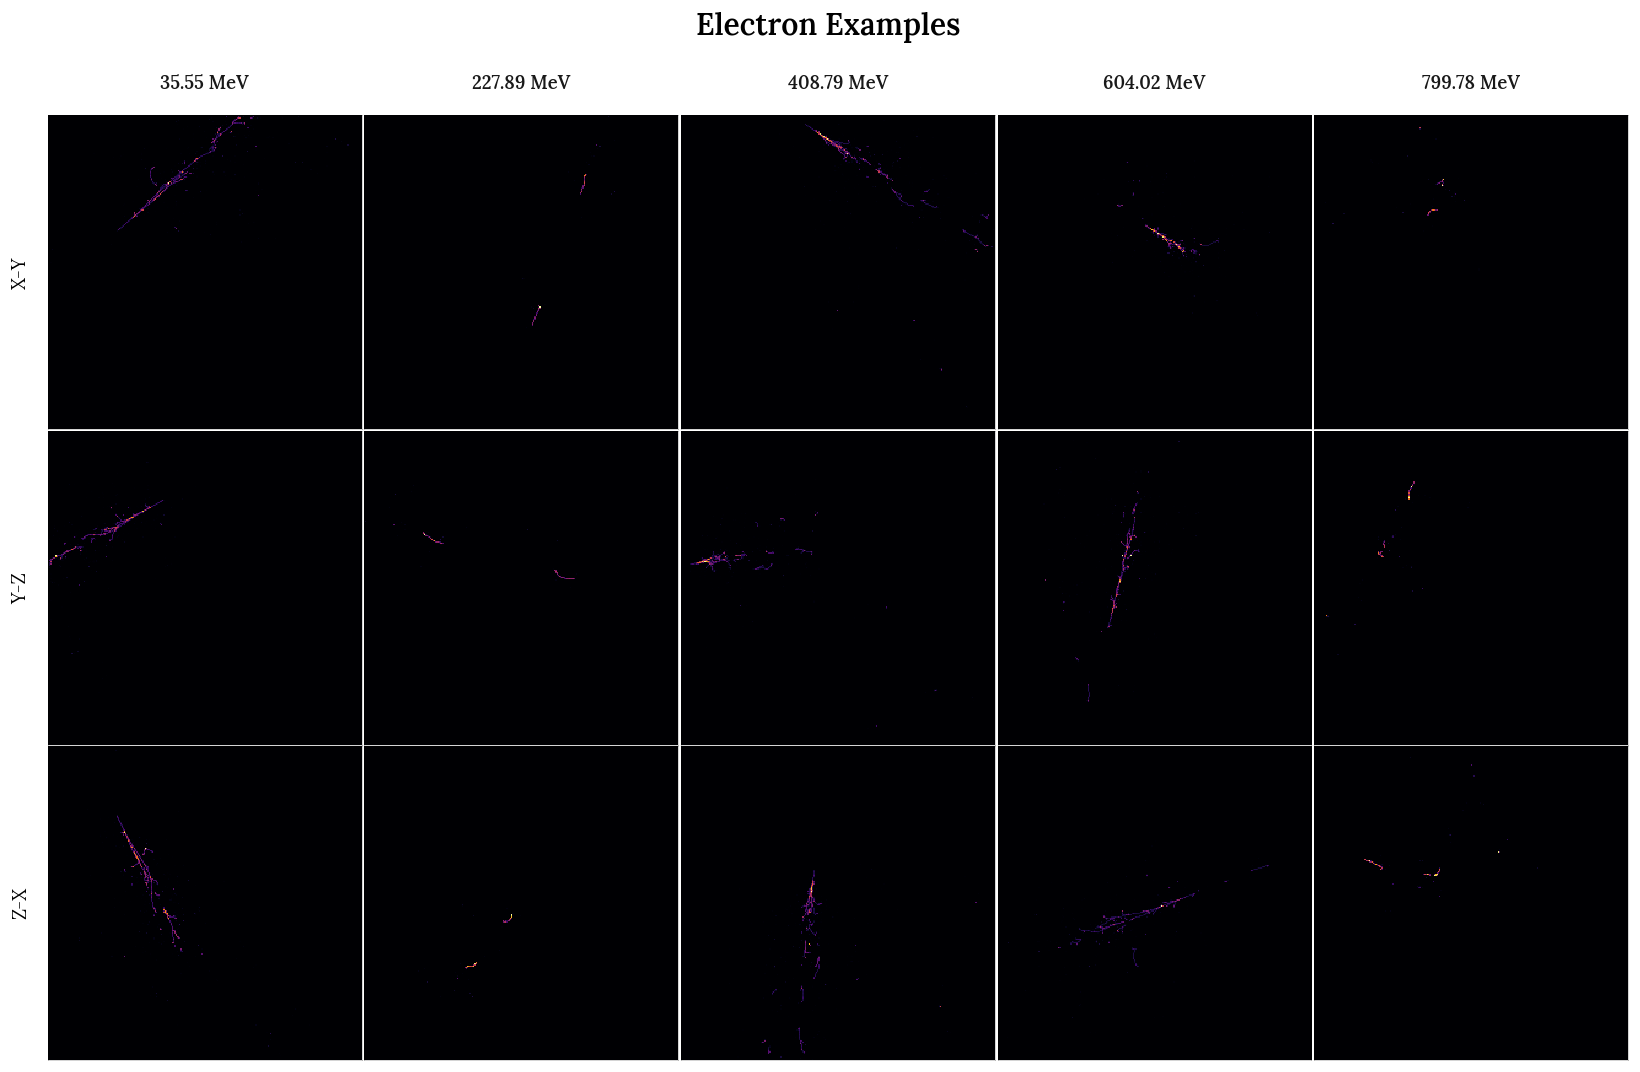

Saved: ../figures/examples_electron.png


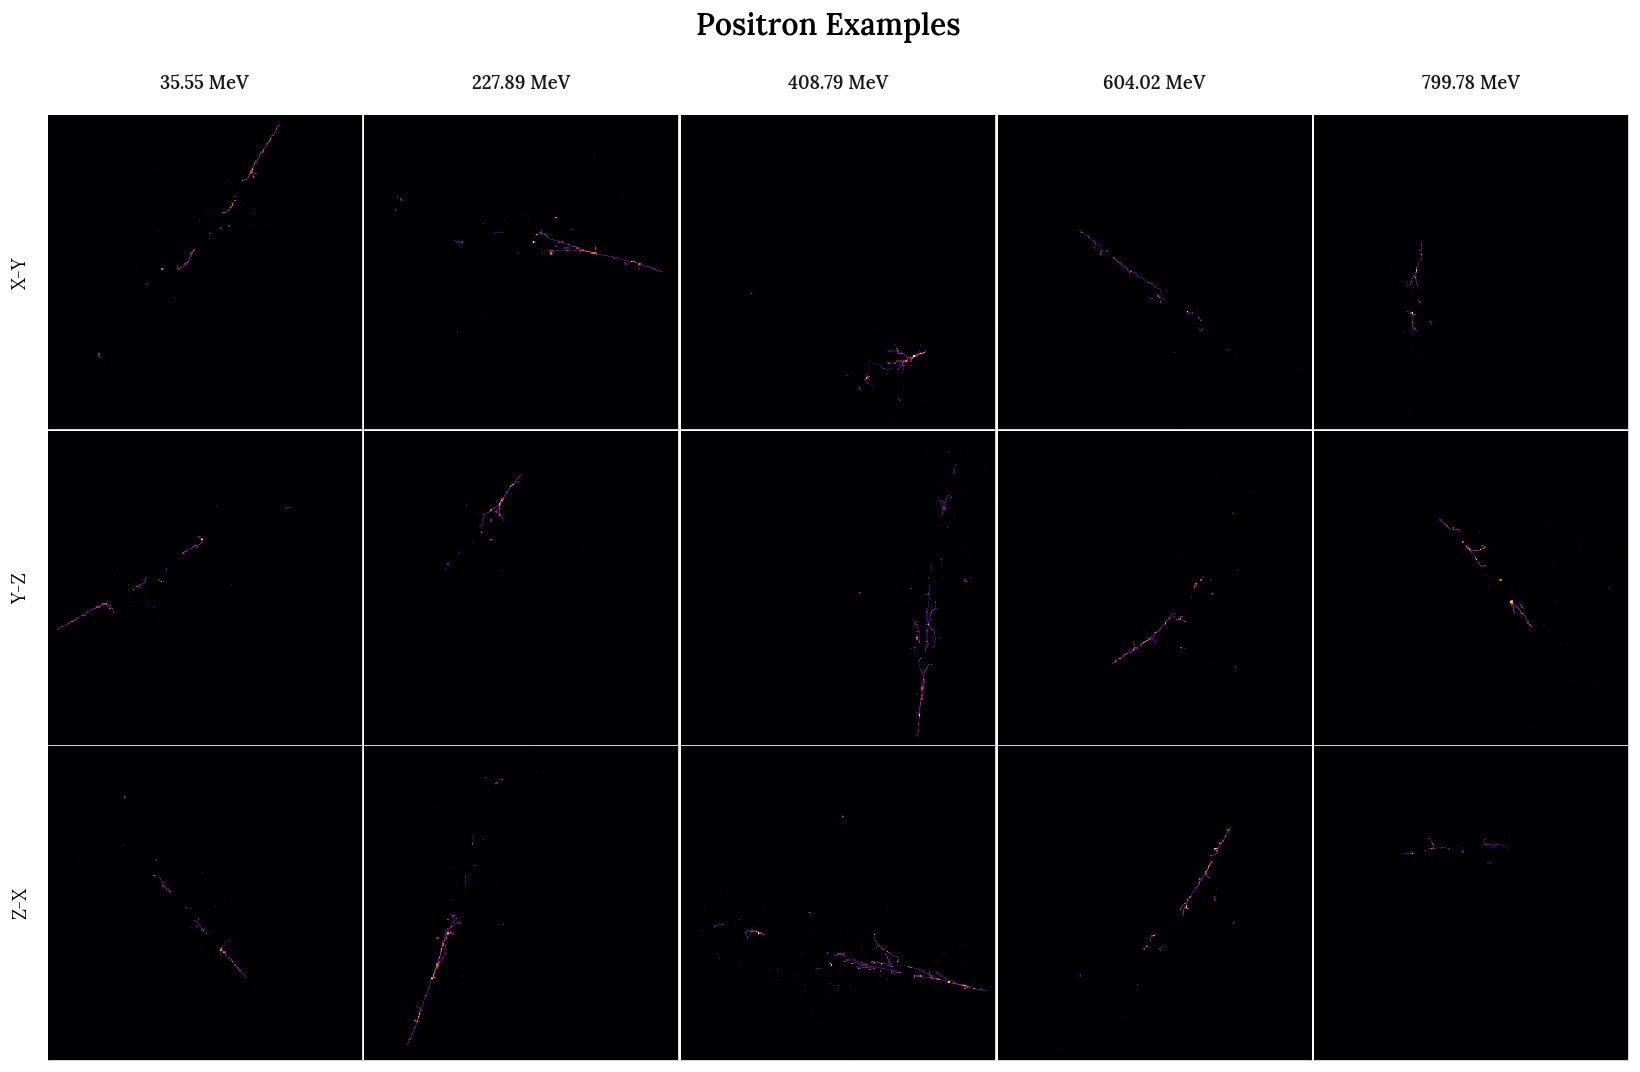

Saved: ../figures/examples_positron.png


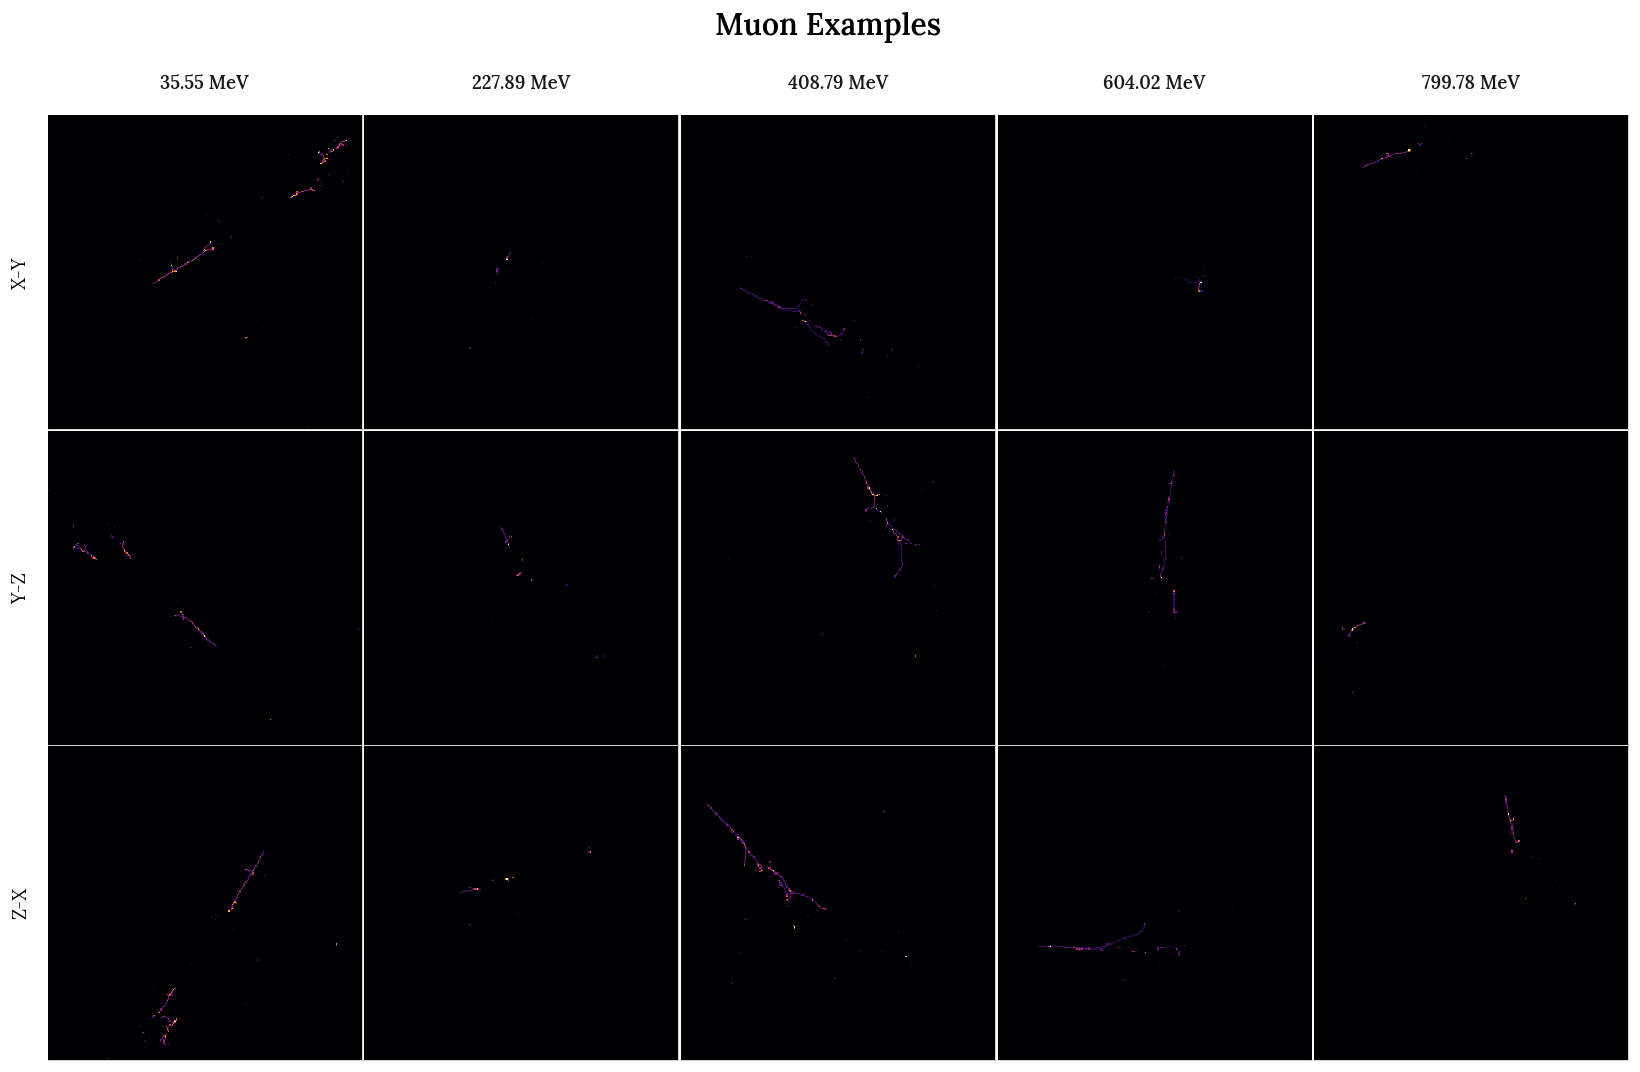

Saved: ../figures/examples_muon.png


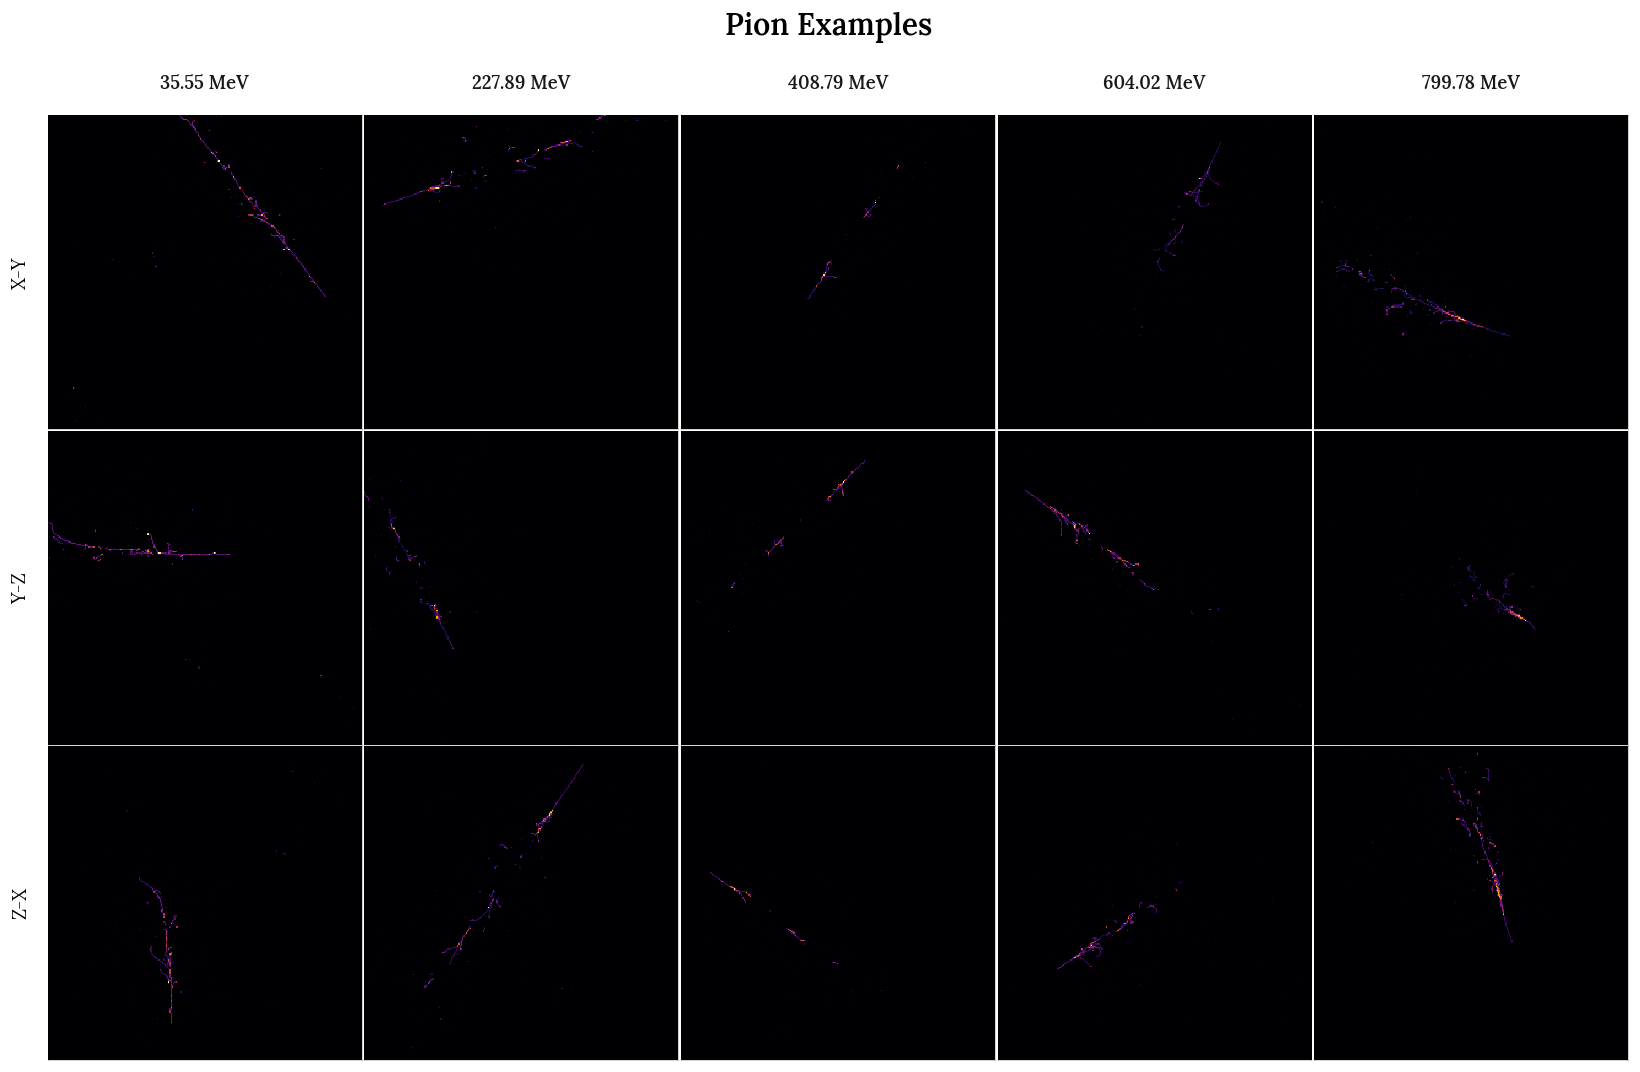

Saved: ../figures/examples_pion.png


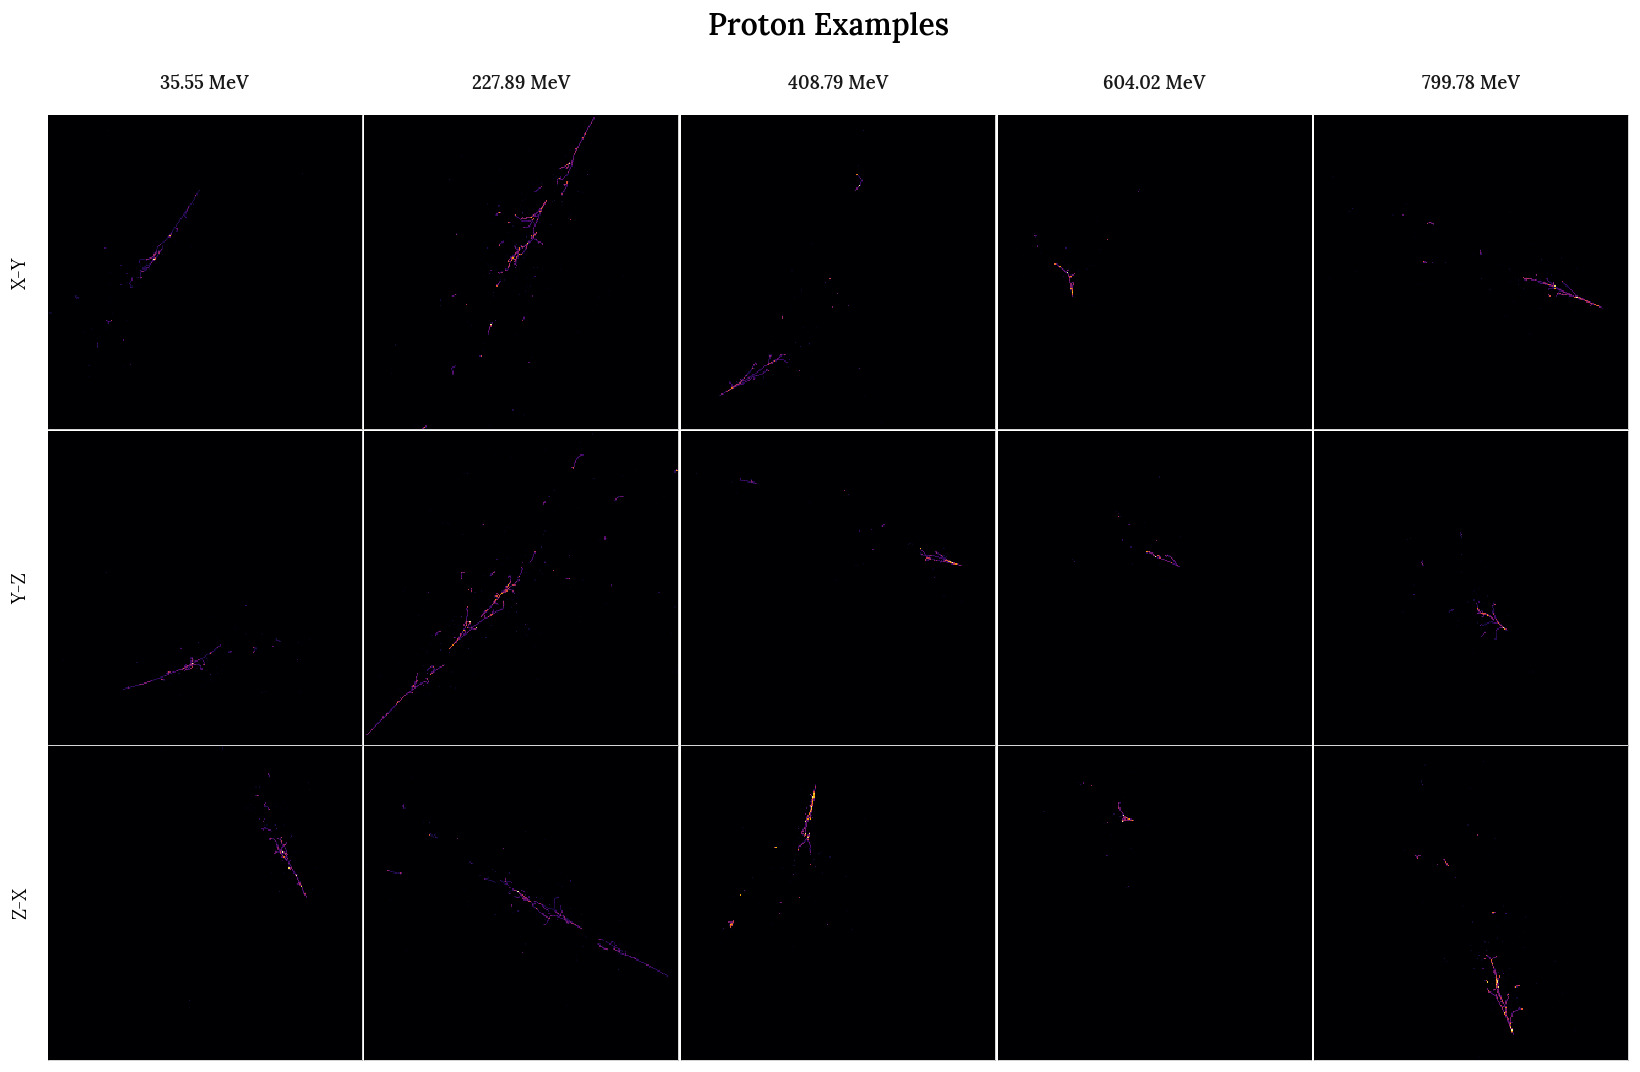

Saved: ../figures/examples_proton.png


In [15]:
# Loop through categories and create one grid figure per particle type
for particle_type in range(no_classes):

    fig, axes = plt.subplots(nrows=no_projections, ncols=no_examples, figsize=(3.2 * no_examples, 3.2 * no_projections))
    axes = np.atleast_2d(axes)

    fig.subplots_adjust(left=0.06, right=0.99, top=0.88, bottom=0.06, wspace=-0.39, hspace=0.005)
    fig.suptitle(f"{particle_names[particle_type]} Examples", fontsize=18, fontweight="bold", x = 0.52, y = 0.97)

    # Loop through examples and projections to fill the grid
    for example in range(no_examples):
        image_index = particle_type * no_examples + example
        momentum = float(np.round(example_momentums[example], 2))

        for projection_plane in range(no_projections):
            ax = axes[projection_plane, example]

            image = example_images[image_index][projection_plane]

            ax.set_facecolor("#0b0b0b")
            ax.set_xticks([])
            ax.set_yticks([])

            ax.imshow(image, cmap="inferno", interpolation="nearest")

            # Plane labels only on first column
            if example == 0:
                ax.set_ylabel(projections[projection_plane], fontsize=11, labelpad=10)

            # Momentum labels only on top row
            if projection_plane == 0:
                ax.set_title(f"{momentum:.2f} MeV", fontsize=11, alpha=0.9, pad=16)

            # Borders
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.5)
                spine.set_alpha(0.2)

    # Save to figures folder
    filename = f"examples_{particle_names[particle_type].lower().replace(' ', '-')}.png"
    out_path = os.path.join(figures_dir, filename)
    fig.savefig(out_path, dpi=220, pad_inches=0.02, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_path}")

## Exploring the Dataset
---

Here the how the truth array data varies for different types of particle is explored. A list of the truth array data names and units is created. Next, the truth array data is looped through, organised by particle type and used to plot histograms.

In [16]:
# Dataset Information about the Truth Arrays
truth_array_info_names = [
    "Particle ID",
    "Total Momentum (MeV)",
    "Momentum $p_x$ (MeV)",
    "Momentum $p_y$ (MeV)",
    "Momentum $p_z$ (MeV)",
    "Production $x$ (cm)",
    "Production $y$ (cm)",
    "Production $z$ (cm)",
]

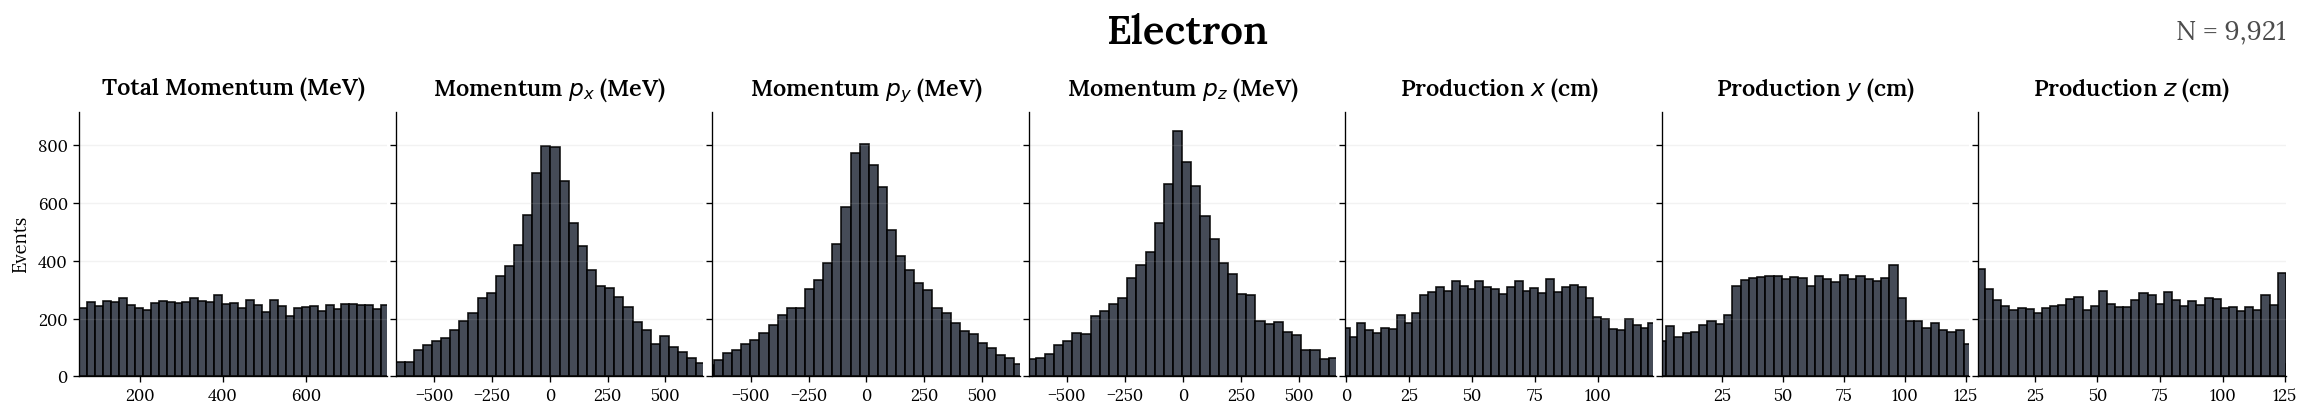

Saved: ../figures/truth_hist_electron.png


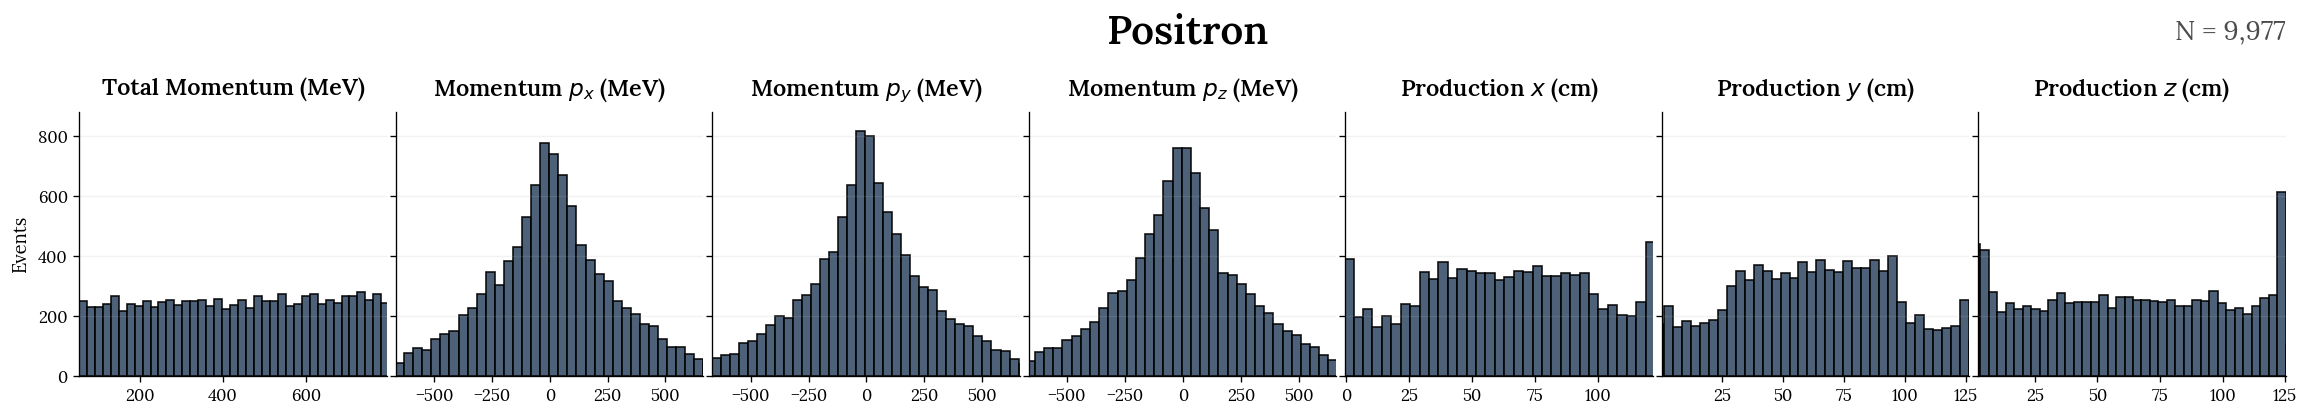

Saved: ../figures/truth_hist_positron.png


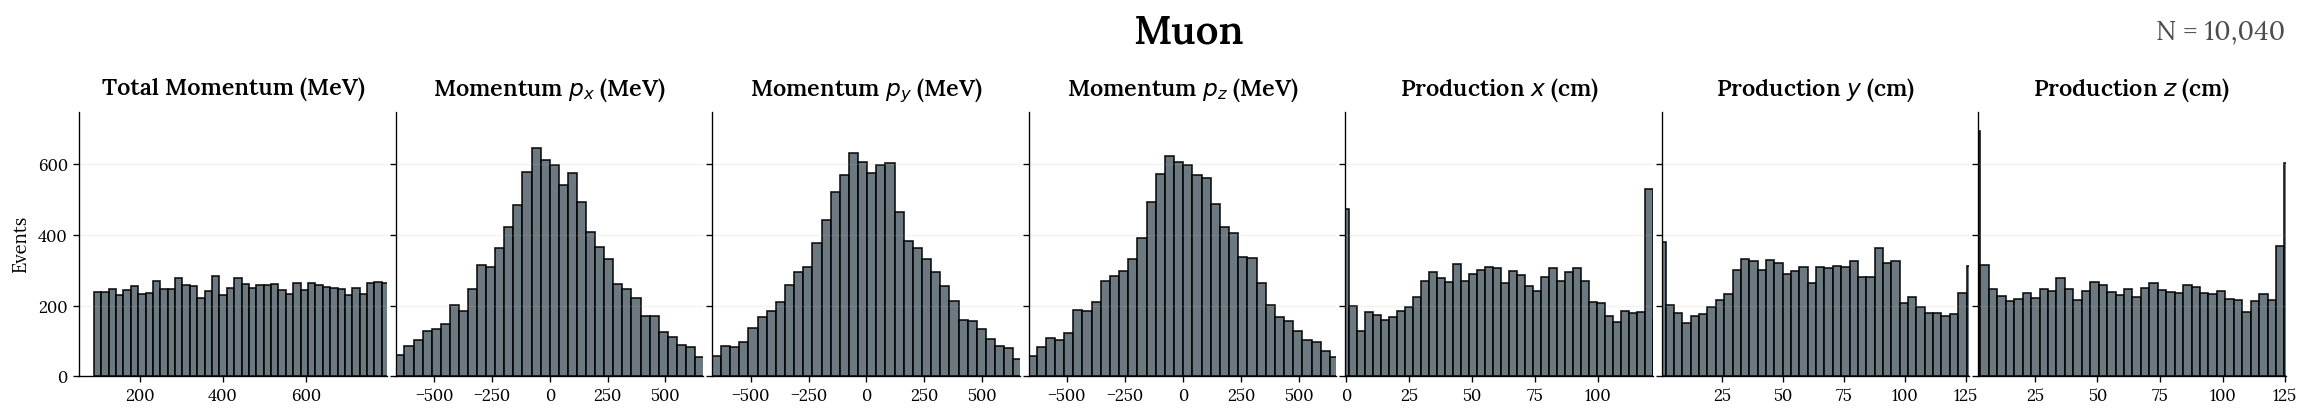

Saved: ../figures/truth_hist_muon.png


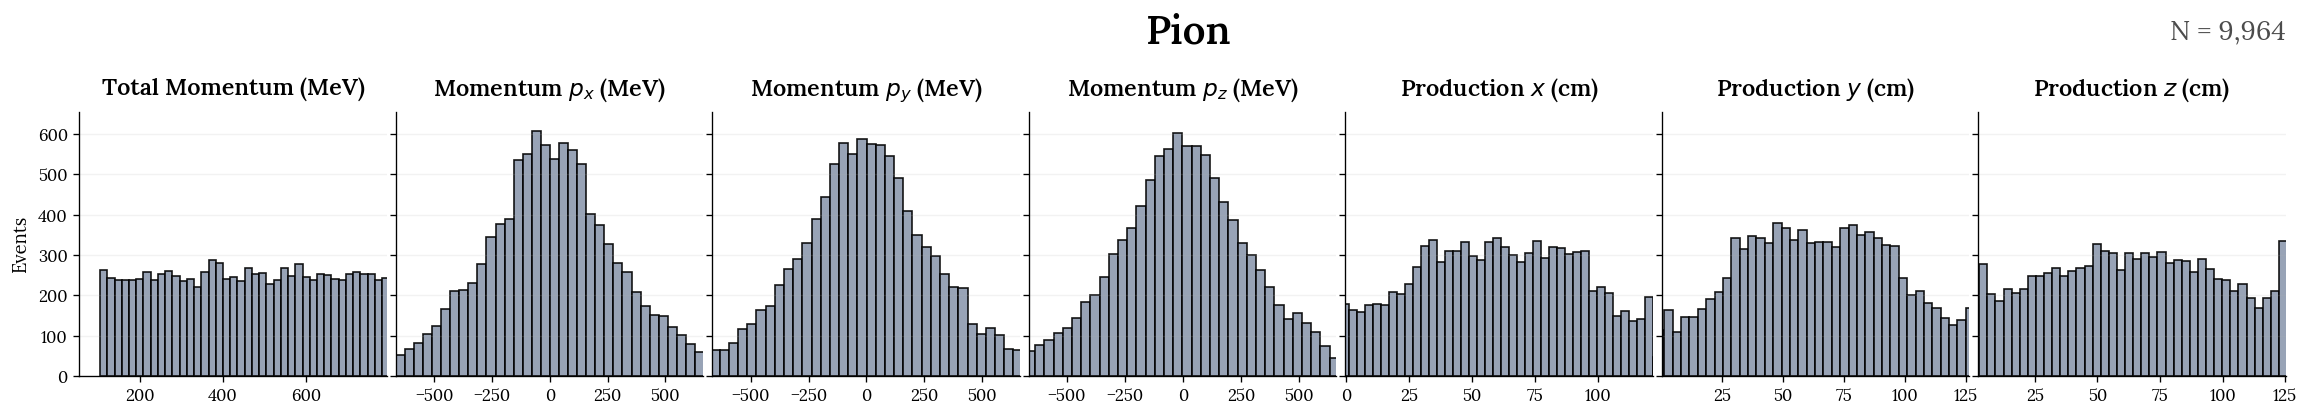

Saved: ../figures/truth_hist_pion.png


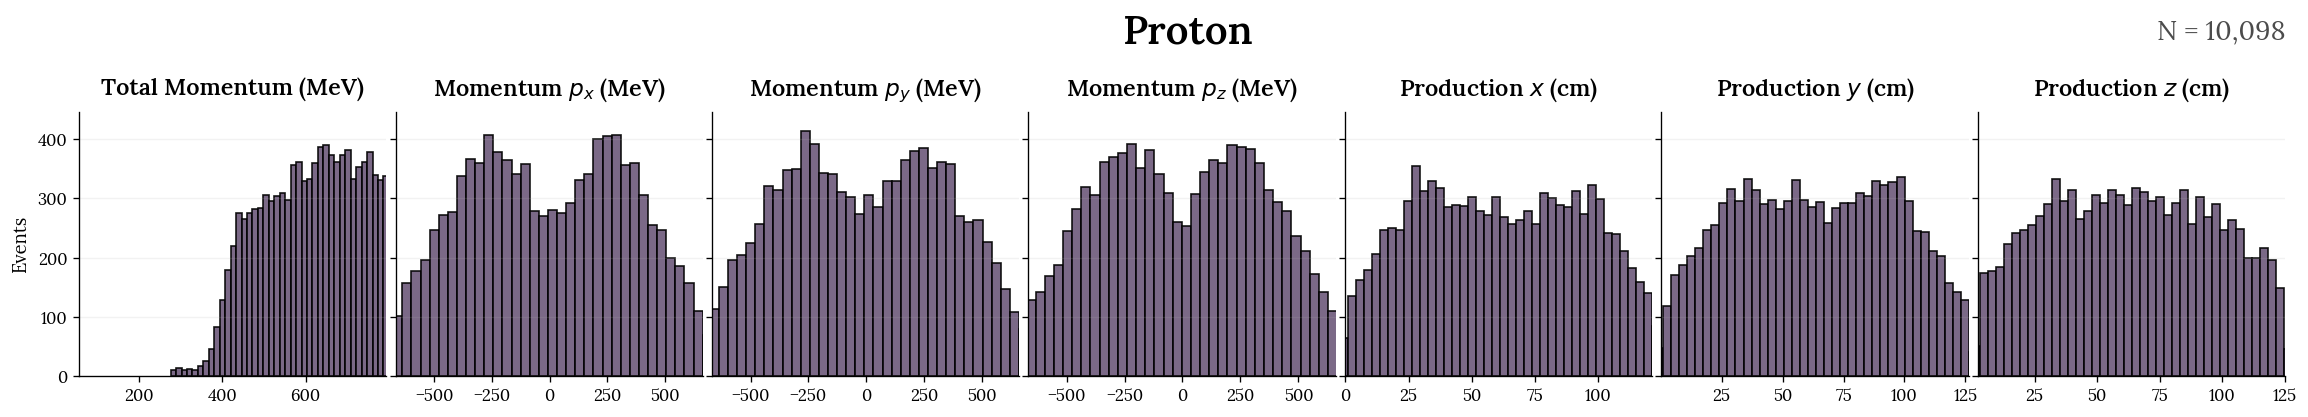

Saved: ../figures/truth_hist_proton.png


In [17]:
palette = ["#313745", "#3A506B", "#5C6B73", "#8D99AE", "#6D597A"]

feature_cols = list(range(1, len(truth_array_info_names)))
n_feats = len(feature_cols)

# Global x-limits per feature for fair comparisons across particle types
global_limits = {}
for col in feature_cols:
    x = truth_train[:, col]
    lo, hi = np.percentile(x, [1, 99])
    global_limits[col] = (lo, hi)

for particle_type in range(no_classes):
    idx = particle_data_indices[particle_type].ravel().astype(int)

    # Shared ymax across features for this particle type
    ymax = 0
    for col in feature_cols:
        counts, _ = np.histogram(truth_train[idx, col], bins=40)
        ymax = max(ymax, counts.max())
    ymax = int(ymax * 1.08)

    # Figure
    fig, axes = plt.subplots(1, n_feats, figsize=(2.75 * n_feats, 3.8), sharey=True)

    if n_feats == 1:
        axes = [axes]

    # Tight spacing
    fig.subplots_adjust(left=0.04, right=0.995, bottom=0.20, top=0.78, wspace=0.03)
    fig.suptitle(f"{particle_names[particle_type]}", fontsize=24, fontweight="bold", y=1, x=0.52)

    # Small annotation for no. of observations
    fig.text(0.995, 0.955, f"N = {len(idx):,}", ha="right", va="center", fontsize=16, alpha=0.7)

    # Plotting each feature
    for ax, col in zip(axes, feature_cols):
        x = truth_train[idx, col]

        ax.hist(x, bins=40, color=palette[particle_type % len(palette)], alpha=0.90, edgecolor=(0, 0, 0, 0))

        ax.set_title(truth_array_info_names[col], fontsize=14, pad=10)

        lo, hi = global_limits[col]
        ax.set_xlim(lo, hi)
        ax.set_ylim(0, ymax)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.16)
        ax.tick_params(axis="both", labelsize=10)

    axes[0].set_ylabel("Events", fontsize=11)

    # Save
    filename = f"truth_hist_{particle_names[particle_type].lower().replace(' ', '-')}.png"
    out_path = os.path.join(figures_dir, filename)

    fig.savefig(out_path, dpi=220, pad_inches=0.02)
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_path}")